## 

In [1]:
import pandas as pd
import chardet

In [12]:
#Searches Player by Stats

import pandas as pd
import chardet

def find_header_rows(file_path, encoding):
    with open(file_path, 'r', encoding=encoding) as file:
        header_rows = []
        for i, line in enumerate(file):
            if 'Player' in line:
                header_rows.append(i+1)
    return header_rows

def filter_players(data_file, criteria_list):
    # Detect the encoding of the file using chardet
    with open(data_file, 'rb') as f:
        result = chardet.detect(f.read())

    # Get the detected encoding
    encoding = result['encoding']

    # Find header rows dynamically
    header_rows = find_header_rows(data_file, encoding)

    # Read the CSV file with the detected encoding and skip header rows
    df = pd.read_csv(data_file, header=1, encoding=encoding, skiprows=header_rows)

    player_list = []

    # Iterate through each player
    for _, player_data in df.iterrows():
        # Flag to check if the player satisfies all criteria
        satisfies_criteria = True

        # Check each criterion
        for criteria in criteria_list:
            column, operator, threshold = criteria['column'], criteria['operator'], criteria['threshold']

            # Evaluate the condition for the current criterion
            if column == 'Tm':
                # Check if the team name matches the threshold
                if threshold != '' and operator == '==' and not player_data[column] == threshold:
                    satisfies_criteria = False
                    break
            else:
                # For other columns, evaluate numerical conditions
                try:
                    # Convert the player_data[column] to a numeric type
                    player_value = float(player_data[column])

                    # Check for 'N/A' and handle it appropriately
                    if pd.notna(player_value) and player_data[column] != 'N/A':
                        if operator == '>' and not player_value > float(threshold):
                            satisfies_criteria = False
                            break
                        elif operator == '<' and not player_value < float(threshold):
                            satisfies_criteria = False
                            break
                        elif operator == '>=' and not player_value >= float(threshold):
                            satisfies_criteria = False
                            break
                        elif operator == '<=' and not player_value <= float(threshold):
                            satisfies_criteria = False
                            break
                    else:
                        satisfies_criteria = False
                        break
                except ValueError:
                    # Handle the case where the value in the column is not numeric
                    satisfies_criteria = False
                    break

        # If the player satisfies all criteria, add them to the list
        if satisfies_criteria:
            # Use player_data['Player'] instead of player
            player_list.append(f"{player_data['Player']}")

    for i, player in enumerate(player_list):
        # Check if '?' is in the player's name
        if '?' in player:
            # Replace '?' with 'c'
            player_list[i] = player.replace('?', 'c')

    return player_list


# Example usage with your specified file path and criteria
season_range_start = input("What season would you like to begin in?")
season_range_end = input("What season would you like to end in?")

for season in range(int(season_range_start), int(season_range_end)+1):
    file_path = fr'C:\Users\gasto\Downloads\Capstone Project Data\TEST{season}.csv'

    criteria_list = [
        {'column': 'Tm', 'operator': '==', 'threshold': ''},
        {'column': 'PTS', 'operator': '>=', 'threshold': 0},
        {'column': 'GS', 'operator': '>=', 'threshold': 82},
        {'column': 'AST', 'operator': '>=', 'threshold': 0}
    ]

    result = filter_players(file_path, criteria_list)

    print(f"\nPLAYERS MATCHING CRITERIA in {season-1}-{season} season:")
    print(result)

    # Example usage to get stats for a specific player with selected stats
    """player_to_lookup = input("\nEnter the player's name to get stats or type 'None':")
    if player_to_lookup != 'None':
        selected_stats = input("Enter the stats to display (comma-separated, or 'all' for all stats):")
        player_stats = get_player_stats(file_path, player_to_lookup, selected_stats)
        print(f"\nStats for {player_to_lookup}:")
        print(player_stats)
    else:
        print('You have chosen not to select a player.')"""


What season would you like to begin in?2019
What season would you like to end in?2024

PLAYERS MATCHING CRITERIA in 2018-2019 season:
['Bradley Beal', 'Tobias Harris', 'Buddy Hield', 'Joe Ingles', 'Reggie Jackson', 'P.J. Tucker', 'Kemba Walker']

PLAYERS MATCHING CRITERIA in 2019-2020 season:
[]

PLAYERS MATCHING CRITERIA in 2020-2021 season:
[]

PLAYERS MATCHING CRITERIA in 2021-2022 season:
['Saddiq Bey', 'Mikal Bridges']

PLAYERS MATCHING CRITERIA in 2022-2023 season:
['Harrison Barnes', 'Mikal Bridges', 'Nikola Vucevic']

PLAYERS MATCHING CRITERIA in 2023-2024 season:
[]


In [11]:
#Searches stats by player

def find_header_rows(file_path, encoding):
    with open(file_path, 'r', encoding=encoding) as file:
        header_rows = []
        for i, line in enumerate(file):
            if 'Player' in line:
                header_rows.append(i+1)

    return header_rows
def get_player_stats(data_file, player_name, selected_stats=None):
    # Detect the encoding of the file using chardet
    with open(data_file, 'rb') as f:
        result = chardet.detect(f.read())

    # Get the detected encoding
    encoding = result['encoding']

    # Find header rows dynamically
    header_rows = find_header_rows(data_file, encoding)

    # Read the CSV file with the detected encoding and skip header rows
    #df = pd.read_csv(data_file, header=1, encoding=encoding, skiprows=header_rows)
    df = pd.read_csv(data_file, header=1, encoding=encoding)
    # Search for the player in the DataFrame
    player_stats = df[df['Player'] == player_name]

    if player_stats.empty:
        return f"No stats found for {player_name}"
    else:
        # If selected_stats is not specified or is 'all', display all stats
        if selected_stats is None or selected_stats.lower() == 'all':
            return player_stats.to_string(index=False)
        else:
            # Display only the selected stats
            selected_stats = [stat.strip() for stat in selected_stats.split(',')]
            return player_stats[selected_stats].to_string(index=False)

season_range_start = input("What season would you like to begin in?")
season_range_end = input("What season would you like to end in?")
player_to_lookup = input("\nEnter the player's name to get stats or type 'None':")
selected_stats = input("Enter the stats to display (comma-separated, or 'all' for all stats):")

for season in range(int(season_range_start), int(season_range_end)+1):
    file_path = fr'C:\Users\gasto\Downloads\Capstone Project Data\TEST{season}.csv'
    player_stats = get_player_stats(file_path, player_to_lookup, selected_stats)
    print(f"\nStats for {player_to_lookup} in {season-1}-{season}:")
    print(player_stats)
 

What season would you like to begin in?2023
What season would you like to end in?2024

Enter the player's name to get stats or type 'None':Paolo Banchero
Enter the stats to display (comma-separated, or 'all' for all stats):all

Stats for Paolo Banchero in 2022-2023:
Rk         Player Pos Age  Tm  G GS   MP  FG  FGA   FG%  3P 3PA   3P%  2P  2PA   2P%  eFG%  FT FTA   FT% ORB DRB TRB AST STL BLK TOV  PF PTS  Year
23 Paolo Banchero  PF  20 ORL 72 72 33.8 6.7 15.6 0.427 1.2   4 0.298 5.5 11.6 0.471 0.465 5.5 7.4 0.738 1.2 5.7 6.9 3.7 0.8 0.5 2.8 2.2  20  2023

Stats for Paolo Banchero in 2023-2024:
Rk         Player Pos Age  Tm  G GS   MP  FG  FGA   FG%  3P 3PA   3P%  2P  2PA   2P%  eFG%  FT FTA   FT% ORB DRB TRB AST STL BLK TOV  PF  PTS  Year
23 Paolo Banchero  PF  21 ORL 20 20 33.4 7.1 14.7 0.481 1.4 3.1 0.443 5.7 11.6 0.491 0.527 4.1 6.1 0.669 1.4 5.5 6.9 4.9 1.1 0.6 3.1 2.3 19.5  2024


In [5]:
#Predicting 2024 MVP


"""Last 10 MVP's (PTS/TRB/AST):
22-23: Joel Embiid (33.1, 10.2, 4.2)
21-22: Nikola Jokić (27.1/13.8/7.9)
20-21: Nikola Jokić (26.4/10.8/8.3)
19-20: Giannis Antetokounmpo (29.5/13.6/5.6)
18-19: Giannis Antetokounmpo (27.7/12.5/5.9)
17-18: James Harden (30.4/5.4/8.8)
16-17: Russell Westbrook (31.6/10.7/10.4)
15-16: Stephen Curry (30.1/5.4/6.7)
14-15: Stephen Curry (23.8/4.3/7.7)
13-14: Kevin Durant (32.0/7.4/5.5)
12-13: LeBron James (26.8/8.0/7.3)
"""
# Player names
players = [
    "Joel Embiid",
    "Nikola Jokic",
    "Nikola Jokic",
    "Giannis Antetokounmpo",
    "Giannis Antetokounmpo",
    "James Harden",
    "Russell Westbrook",
    "Stephen Curry",
    "Stephen Curry",
    "Kevin Durant",
    "LeBron James",
]

# Corresponding stats
stats = [
    (33.1, 10.2, 4.2),
    (27.1, 13.8, 7.9),
    (26.4, 10.8, 8.3),
    (29.5, 13.6, 5.6),
    (27.7, 12.5, 5.9),
    (30.4, 5.4, 8.8),
    (31.6, 10.7, 10.4),
    (30.1, 5.4, 6.7),
    (23.8, 4.3, 7.7),
    (32.0, 7.4, 5.5),
    (26.8, 8.0, 7.3),
]

# Calculate average stats
avg_pts = sum(stat[0] for stat in stats) / len(stats)
avg_trb = sum(stat[1] for stat in stats) / len(stats)
avg_ast = sum(stat[2] for stat in stats) / len(stats)

criteria_list = [
        {'column': 'Tm', 'operator': '==', 'threshold': ''},
        {'column': 'PTS', 'operator': '>=', 'threshold': avg_pts},
        {'column': 'TRB', 'operator': '>=', 'threshold': avg_trb},
        {'column': 'AST', 'operator': '>=', 'threshold': avg_ast}
    ]
data_file=fr'C:\Users\gasto\Downloads\Capstone Project Data\TEST2024.csv'
print('Players Matching MVP Averages in 2023-2024 Season: ')
filter_players(data_file, criteria_list)

Players Matching MVP Averages in 2023-2024 Season: 


['Nikola Jokic']

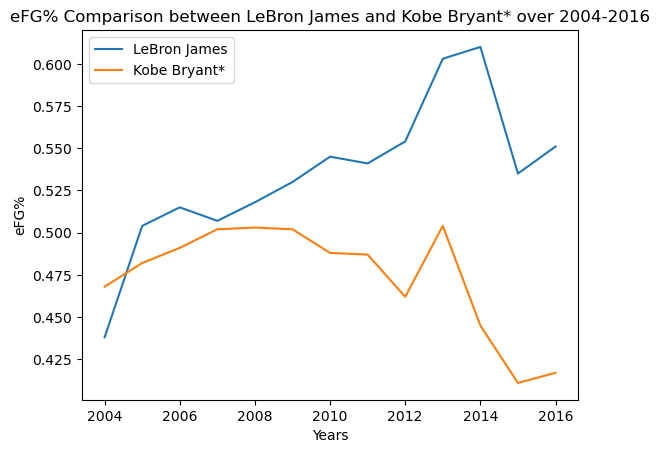

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import chardet

def get_player_stats(data_file, player_name, selected_stats=None):
    # Detect the encoding of the file using chardet
    with open(data_file, 'rb') as f:
        result = chardet.detect(f.read())

    # Get the detected encoding
    encoding = result['encoding']

    # Read the CSV file with the detected encoding
    df = pd.read_csv(data_file, header=1, encoding=encoding)

    # Reset the index
    #df.reset_index(drop=True, inplace=True)

    # Search for the player in the DataFrame
    player_stats = df[df['Player'] == player_name]

    if player_stats.empty:
        return None
    else:
        # If selected_stats is not specified or is 'all', display all stats
        if selected_stats is None or selected_stats.lower() == 'all':
            return player_stats
        else:
            # Display only the selected stats
            selected_stats = [stat.strip() for stat in selected_stats.split(',')]
            return player_stats[selected_stats]

def plot_player_comparison(player1, player2, stat, years):
    # Initialize lists to store data
    data_player1 = []
    data_player2 = []

    # Iterate through the specified years
    for year in range(years[0], years[1] + 1):
        file_path = fr'C:\Users\gasto\Downloads\Capstone Project Data\TEST{year}.csv'

        # Get stats for the two players
        stats_player1 = get_player_stats(file_path, player1, stat)
        stats_player2 = get_player_stats(file_path, player2, stat)

        if stats_player1 is not None and stats_player2 is not None:
            # Extract the relevant data for the specified stat
            data_player1.append(pd.to_numeric(stats_player1[stat].values[0]))
            data_player2.append(pd.to_numeric(stats_player2[stat].values[0]))

    # Plot the raw data without normalization
    plt.plot(range(years[0], years[1] + 1), data_player1, label=player1)
    plt.plot(range(years[0], years[1] + 1), data_player2, label=player2)

    # Add labels and legend
    plt.xlabel('Years')
    plt.ylabel(stat)  # Use the raw stat name
    plt.title(f'{stat} Comparison between {player1} and {player2} over {years[0]}-{years[1]}')
    plt.legend()
    plt.show()

# Example usage
player1 = 'LeBron James'
player2 = 'Kobe Bryant*'
stat = 'eFG%'  # Change to the desired stat
years = [2004, 2016]  # Change to the desired range of years

plot_player_comparison(player1, player2, stat, years)
